In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
ADAPTER_ID = "DLCS/contract-clause-phi3-lora"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

c:\Contract-clause-qlora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 195/195 [00:15<00:00, 12.27it/s]


In [4]:
from huggingface_hub import login
login()

In [5]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '68a1806005b464d82aacbdb4', 'name': 'DLCS', 'fullname': 'Siddharth Deeti', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1790812800, 'isPro': False, 'avatarUrl': '/avatars/f9207351929fe9a7150a04f7fafc7032.svg', 'orgs': [], 'auth': {'type': 'oauth', 'expiresAt': '2026-10-06T05:57:58.000Z'}}


In [6]:
model = PeftModel.from_pretrained(base_model, ADAPTER_ID)
model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Phi3ForCausalLM(
      (model): Phi3Model(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
        (layers): ModuleList(
          (0-31): 32 x Phi3DecoderLayer(
            (self_attn): Phi3Attention(
              (o_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
             

In [8]:
import json

# Load all your 41 categories + "None" from wherever they live -- 
# easiest: read them from your train/val/test data directly
categories = set()
from contract_clause_qlora.cuad import PROJECT_ROOT

with open(PROJECT_ROOT / "data" / "processed" / "test.jsonl", encoding="utf-8") as f:
    for line in f:
        categories.add(json.loads(line)["category"])

print(len(categories), "unique categories")

max_len = 0
for cat in categories:
    token_count = len(tokenizer.encode(cat))
    max_len = max(max_len, token_count)

print("Max category token length:", max_len)

42 unique categories
Max category token length: 15


**Note:** the cell below runs the full evaluation loop over all 2,784 test examples for both models (~36 minutes). It has already been run; output is saved to `data/eval_results.jsonl`. Skip it and jump to the next section unless you specifically need to regenerate predictions.

In [28]:
import json
import time
from contract_clause_qlora.cuad import PROJECT_ROOT

test_examples = []
with open(PROJECT_ROOT / "data" / "processed" / "test.jsonl", encoding="utf-8") as f:
    for line in f:
        test_examples.append(json.loads(line))

print(f"Total test examples: {len(test_examples)}")

MAX_NEW_TOKENS = 18
OUTPUT_PATH = PROJECT_ROOT / "data" / "eval_results.jsonl"

model.eval()

start = time.time()

with open(OUTPUT_PATH, "w", encoding="utf-8") as out_f:
    for i, ex in enumerate(test_examples):
        prompt = ex["prompt"]  # <- FIX: use the already-correct prompt directly, don't re-call format_example
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        prompt_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            out_ft = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
            finetuned_pred = tokenizer.decode(out_ft[0][prompt_len:], skip_special_tokens=True).strip()

            with model.disable_adapter():
                out_base = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
                baseline_pred = tokenizer.decode(out_base[0][prompt_len:], skip_special_tokens=True).strip()

        result = {
            "contract_id": ex["contract_id"],
            "true_category": ex["category"],
            "finetuned_pred": finetuned_pred,
            "baseline_pred": baseline_pred,
        }
        out_f.write(json.dumps(result) + "\n")
        out_f.flush()

        if (i + 1) % 100 == 0:
            elapsed = time.time() - start
            print(f"{i+1}/{len(test_examples)} done ({elapsed:.0f}s elapsed)")

print(f"Done. Total time: {(time.time() - start)/60:.1f} minutes")

Total test examples: 2784
100/2784 done (102s elapsed)
200/2784 done (206s elapsed)
300/2784 done (283s elapsed)
400/2784 done (364s elapsed)
500/2784 done (464s elapsed)
600/2784 done (563s elapsed)
700/2784 done (657s elapsed)
800/2784 done (744s elapsed)
900/2784 done (826s elapsed)
1000/2784 done (915s elapsed)
1100/2784 done (992s elapsed)
1200/2784 done (1073s elapsed)
1300/2784 done (1150s elapsed)
1400/2784 done (1244s elapsed)
1500/2784 done (1313s elapsed)
1600/2784 done (1393s elapsed)
1700/2784 done (1461s elapsed)
1800/2784 done (1523s elapsed)
1900/2784 done (1595s elapsed)
2000/2784 done (1661s elapsed)
2100/2784 done (1733s elapsed)
2200/2784 done (1805s elapsed)
2300/2784 done (1871s elapsed)
2400/2784 done (1933s elapsed)
2500/2784 done (1996s elapsed)
2600/2784 done (2064s elapsed)
2700/2784 done (2130s elapsed)
Done. Total time: 36.4 minutes


In [11]:
import json
from contract_clause_qlora.cuad import PROJECT_ROOT

true_categories = set()
with open(PROJECT_ROOT / "data" / "eval_results.jsonl", encoding="utf-8") as f:
    for line in f:
        true_categories.add(json.loads(line)["true_category"])

print(len(true_categories))
print(sorted(true_categories))

42
['Affiliate License-Licensee', 'Affiliate License-Licensor', 'Agreement Date', 'Anti-Assignment', 'Audit Rights', 'Cap On Liability', 'Change Of Control', 'Competitive Restriction Exception', 'Covenant Not To Sue', 'Document Name', 'Effective Date', 'Exclusivity', 'Expiration Date', 'Governing Law', 'Insurance', 'Ip Ownership Assignment', 'Irrevocable Or Perpetual License', 'Joint Ip Ownership', 'License Grant', 'Liquidated Damages', 'Minimum Commitment', 'Most Favored Nation', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Non-Compete', 'Non-Disparagement', 'Non-Transferable License', 'None', 'Notice Period To Terminate Renewal', 'Parties', 'Post-Termination Services', 'Price Restrictions', 'Renewal Term', 'Revenue/Profit Sharing', 'Rofr/Rofo/Rofn', 'Source Code Escrow', 'Termination For Convenience', 'Third Party Beneficiary', 'Uncapped Liability', 'Unlimited/All-You-Can-Eat-License', 'Volume Restriction', 'Warranty Duration']


In [12]:
from contract_clause_qlora.cuad import parse_prediction


In [13]:
test_pred = "Document Name."
print(parse_prediction(test_pred, true_categories))

test_pred2 = "document name"
print(parse_prediction(test_pred2, true_categories))

test_pred3 = "Some Made Up Category"
print(parse_prediction(test_pred3, true_categories))

Document Name
Document Name
INVALID


In [14]:
import json
from contract_clause_qlora.cuad import PROJECT_ROOT

results = []
with open(PROJECT_ROOT / "data" / "eval_results.jsonl", encoding="utf-8") as f:
    for line in f:
        results.append(json.loads(line))

for r in results:
    r["finetuned_parsed"] = parse_prediction(r["finetuned_pred"], true_categories)
    r["baseline_parsed"] = parse_prediction(r["baseline_pred"], true_categories)

finetuned_invalid = sum(1 for r in results if r["finetuned_parsed"] == "INVALID")
baseline_invalid = sum(1 for r in results if r["baseline_parsed"] == "INVALID")

print(f"Fine-tuned invalid rate: {finetuned_invalid}/{len(results)} = {finetuned_invalid/len(results)*100:.2f}%")
print(f"Baseline invalid rate: {baseline_invalid}/{len(results)} = {baseline_invalid/len(results)*100:.2f}%")

Fine-tuned invalid rate: 14/2784 = 0.50%
Baseline invalid rate: 1628/2784 = 58.48%


In [15]:
finetuned_correct = sum(1 for r in results if r["finetuned_parsed"] == r["true_category"])
baseline_correct = sum(1 for r in results if r["baseline_parsed"] == r["true_category"])

finetuned_accuracy = finetuned_correct / len(results)
baseline_accuracy = baseline_correct / len(results)

print(f"Fine-tuned accuracy: {finetuned_accuracy*100:.2f}%")
print(f"Baseline accuracy: {baseline_accuracy*100:.2f}%")

Fine-tuned accuracy: 62.50%
Baseline accuracy: 21.55%


In [16]:
from sklearn.metrics import classification_report

all_labels = sorted(true_categories) + ["INVALID"]

y_true = [r["true_category"] for r in results]
y_pred_finetuned = [r["finetuned_parsed"] for r in results]
y_pred_baseline = [r["baseline_parsed"] for r in results]

print("=== FINE-TUNED ===")
print(classification_report(y_true, y_pred_finetuned, labels=all_labels, zero_division=0))

print("=== BASELINE ===")
print(classification_report(y_true, y_pred_baseline, labels=all_labels, zero_division=0))

=== FINE-TUNED ===
                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.29      0.42      0.34        24
        Affiliate License-Licensor       0.50      0.22      0.31         9
                    Agreement Date       0.58      0.31      0.41        48
                   Anti-Assignment       0.70      0.92      0.80        53
                      Audit Rights       0.49      1.00      0.66        42
                  Cap On Liability       0.55      0.59      0.57        73
                 Change Of Control       0.44      0.80      0.57        20
 Competitive Restriction Exception       0.13      0.50      0.21        12
               Covenant Not To Sue       0.65      0.79      0.71        14
                     Document Name       0.55      0.96      0.70        55
                    Effective Date       0.34      0.66      0.45        41
                       Exclusivity       0.36      0.43      0.39   

In [21]:
import json
from contract_clause_qlora.cuad import PROJECT_ROOT

test_examples = []
with open(PROJECT_ROOT / "data" / "processed" / "test.jsonl", encoding="utf-8") as f:
    for line in f:
        test_examples.append(json.loads(line))


In [22]:
none_misclassified_indices = [
    i for i, r in enumerate(results)
    if r["true_category"] == "None" and r["finetuned_parsed"] not in ("None", "INVALID")
]

print(f"Total None misclassified as a real category: {len(none_misclassified_indices)}")

for i in none_misclassified_indices[:15]:
    r = results[i]
    clause = test_examples[i]["clause_text"]
    print(f"Predicted: {r['finetuned_parsed']}")
    print(f"Clause text: {clause[:200]}")
    print("---")

Total None misclassified as a real category: 678
Predicted: Cap On Liability
Clause text: INDEMNIFICATION   A.
---
Predicted: Audit Rights
Clause text: In addition, EDGE exercise of such right is for EDGE' benefit alone and shall confer no rights to Subcontractor or to any third party.
---
Predicted: Warranty Duration
Clause text: EDGE shall have the right without prejudice to any other rights or remedies available to it, (i) to make such repairs and offset the cost thereof against any amounts owed to be paid by EDGE to Subcont
---
Predicted: Insurance
Clause text: Subcontractor shall indemnify, defend and hold harmless EDGE and Customer and both of their subsidiaries, directors, shareholders, partners, principals (disclosed or undisclosed), employees, agents an
---
Predicted: Warranty Duration
Clause text: NOTICE OF MATERIAL DEFECTS   Subcontractor agrees to promptly notify EDGE upon learning of any material defect, misstatement or omission in rendering any Work.
---
Predicted: Uncapp

In [23]:
from collections import Counter

mismatches = Counter()

for r in results:
    true_cat = r["true_category"]
    pred_cat = r["finetuned_parsed"]
    if true_cat != pred_cat:
        mismatches[(true_cat, pred_cat)] += 1

top_mismatches = mismatches.most_common(20)

for (true_cat, pred_cat), count in top_mismatches:
    print(f"{count:4d}  True: {true_cat:35s} -> Predicted: {pred_cat}")

  77  True: None                                -> Predicted: Parties
  48  True: None                                -> Predicted: License Grant
  44  True: None                                -> Predicted: Volume Restriction
  43  True: None                                -> Predicted: Document Name
  42  True: None                                -> Predicted: Non-Disparagement
  37  True: None                                -> Predicted: Audit Rights
  36  True: None                                -> Predicted: Ip Ownership Assignment
  33  True: Agreement Date                      -> Predicted: Effective Date
  29  True: None                                -> Predicted: Competitive Restriction Exception
  25  True: None                                -> Predicted: Cap On Liability
  22  True: None                                -> Predicted: Post-Termination Services
  21  True: None                                -> Predicted: Warranty Duration
  21  True: None                    

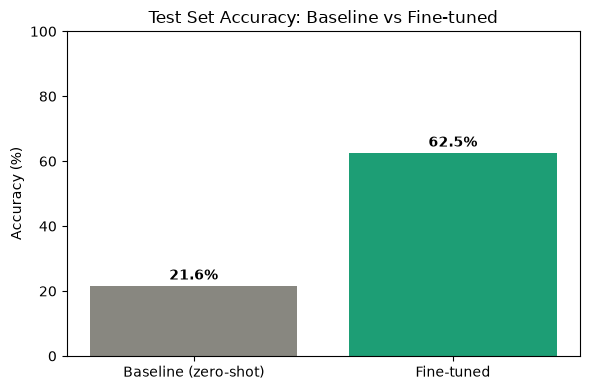

In [24]:
import matplotlib.pyplot as plt

models = ["Baseline (zero-shot)", "Fine-tuned"]
accuracies = [baseline_accuracy * 100, finetuned_accuracy * 100]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, accuracies, color=["#888780", "#1D9E75"])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Test Set Accuracy: Baseline vs Fine-tuned")
ax.set_ylim(0, 100)

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "assets" / "accuracy_comparison.png", dpi=150)
plt.show()

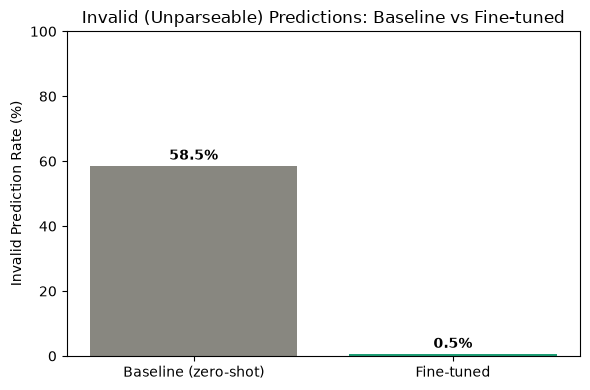

In [25]:
invalid_rates = [baseline_invalid/len(results)*100, finetuned_invalid/len(results)*100]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, invalid_rates, color=["#888780", "#1D9E75"])
ax.set_ylabel("Invalid Prediction Rate (%)")
ax.set_title("Invalid (Unparseable) Predictions: Baseline vs Fine-tuned")
ax.set_ylim(0, 100)

for bar, val in zip(bars, invalid_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "assets" / "invalid_rate_comparison.png", dpi=150)
plt.show()

## Results and Discussion

### Headline results

Fine-tuning Phi-3-mini via QLoRA produced a substantial improvement over the zero-shot baseline on the held-out test set (2,784 examples, natural class distribution, never used for training or checkpoint selection):

| Metric | Baseline (zero-shot) | Fine-tuned |
|---|---|---|
| Accuracy | 21.6% | 62.5% |
| Invalid prediction rate | 58.5% | 0.5% |

The invalid-rate gap is arguably the more striking finding of the two. Over half the time, the zero-shot baseline doesn't produce a recognizable category label at all — it rambles, guesses at unrelated content, or refuses outright. Fine-tuning didn't just improve *which* category gets picked; it taught the model to reliably produce valid, structured output in the first place, which is a distinct and important capability from raw accuracy.

![Accuracy comparison](../assets/accuracy_comparison.png)
![Invalid rate comparison](../assets/invalid_rate_comparison.png)

### Per-category performance

The fine-tuned model performs strongly on well-represented, distinctive categories: `Governing Law` (F1 0.93), `Parties` (F1 0.86), `Insurance` (F1 0.81), and `Anti-Assignment` (F1 0.80) all show the model has learned meaningful, generalizable distinctions rather than just memorizing the majority class.

Performance is far weaker — and statistically unreliable — for the rarest categories. `Price Restrictions` has a test support of exactly 1, `Non-Disparagement` has 2, and several others sit in single digits. Precision/recall/F1 for these categories should be read as illustrative, not reliable — a single misclassified example can swing recall from 0% to 100%. This is a known, deliberate limitation of the project's scope (see below), not a modeling failure to fix.

### Investigating the "None" recall gap

The `None` class — the largest single category (support 1,392) — shows an interesting asymmetry: precision 0.98, recall 0.50. When the model predicts `None`, it is almost always correct; but it misses roughly half of the true `None` examples, instead assigning them a specific category.

A qualitative review of 15 real false-negative examples (`true_category == "None"`, predicted a real category) found a genuine mix of two distinct causes, not one:

- **Annotation gaps in the source data.** Several misclassifications look like defensible, even arguably *better*, answers than the ground truth. One example: a repeated contract title ("STRATEGIC ALLIANCE AGREEMENT 'EDGE-FTE', Page 14") was predicted as `Document Name`, even though CUAD's original annotators appear to have only tagged the document name's first occurrence in the contract, not later repeats. This is evidence that some fraction of the `None` label reflects unannotated-but-real clause language, not genuinely negative text.
- **Genuine model imprecision on short, low-context boilerplate.** Other misclassifications look like real errors: a near-empty "INDEMNIFICATION A." section header was predicted as `Cap On Liability` — a stretch, with too little text to support real disambiguation.

This qualitative sample (15 examples) is illustrative, not a rigorous statistic, and shouldn't be read as a precise measured split between the two causes. But the honest conclusion is that the recall gap reflects a real combination of label ambiguity in the source dataset and genuine model imprecision — not purely one or the other.

Practically, this error pattern (high precision, moderate recall on `None`) is arguably a safe failure mode for the intended use case: a contract-review assistant that occasionally over-flags boilerplate as a specific clause type costs a reviewer a few seconds dismissing a false positive, while a model that instead under-flagged (mislabeling a real clause as `None`) would risk missing something that actually mattered.

### Confusion patterns

Looking at the most frequent (true category → predicted category) mismatches beyond `None`, three specific, interpretable patterns emerge:

- **`Agreement Date` → `Effective Date`** (33 occurrences) — these categories are semantically adjacent; both describe dates tied to when an agreement takes effect, and the distinction is a genuinely fine one even for a human reader.
- **`Cap On Liability` → `Uncapped Liability`** (18 occurrences) — despite being near-opposite concepts, these categories share heavy vocabulary and boilerplate structure ("liability," standard limitation-of-liability phrasing), suggesting the model is pattern-matching on surface vocabulary in some cases rather than fully resolving the semantic distinction.
- **`License Grant` → `Irrevocable Or Perpetual License`** (18 occurrences) — these concepts frequently co-occur in real contract language (license grants are often described as irrevocable or perpetual in the same clause), making this a reasonable, if imprecise, confusion.

A related, smaller-scale observation: several `None` misclassifications appear to be triggered by surface lexical cues rather than deeper understanding — for example, a clause using the word "warrants" was predicted as `Warranty Duration`, even where the surrounding context didn't actually describe a warranty period. This is a useful, honest illustration of the model's current limitations: it has learned real, useful signal, but some of that signal is closer to keyword association than full semantic comprehension.

### Known limitations

This project made several deliberate scope decisions, each documented as they were made:

- **Single-label classification only.** Multi-label clause classification (a single clause matching multiple categories) was explicitly out of scope for this MVP.
- **Rare category support.** Several categories have fewer than 10 test examples (and as few as 1), making their individual metrics directional rather than statistically reliable. This is reported transparently via the `support` column rather than hidden or engineered around.
- **Reduced training scope due to compute constraints.** The original training plan (category cap of 600, 3 epochs, ~1,905 steps) was reduced to a category cap of 80 and 2 epochs (~376 steps) after extensive debugging revealed that Colab's free-tier T4 GPU (Turing architecture, no native bf16 support) combined with a documented `bitsandbytes`/PyTorch `GradScaler` bug forced disabling mixed-precision training entirely. Full-precision (fp32) training at the original scope was estimated at ~55 hours — infeasible on free-tier compute. The reduced scope still produced a healthy, converged training run (~3 hours), but likely leaves some accuracy on the table relative to the original plan.
- **`None`-class construction methodology.** Negative examples were constructed from unannotated text gaps in CUAD's original contracts, not independently verified as true negatives. As discussed above, this appears to introduce some genuine label noise into the `None` class specifically.